<a href="https://colab.research.google.com/github/Dima-BR/machine-learning-projects/blob/main/Diabetes_Predection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetes Predection

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# For modling
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, recall_score, f1_score

plt.style.use('fivethirtyeight')

import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [4]:
df = pd.read_csv('/content/diabetes.csv')

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.shape

(768, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
df.duplicated().sum()

np.int64(0)

# Analysis

In [ ]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


<Axes: >

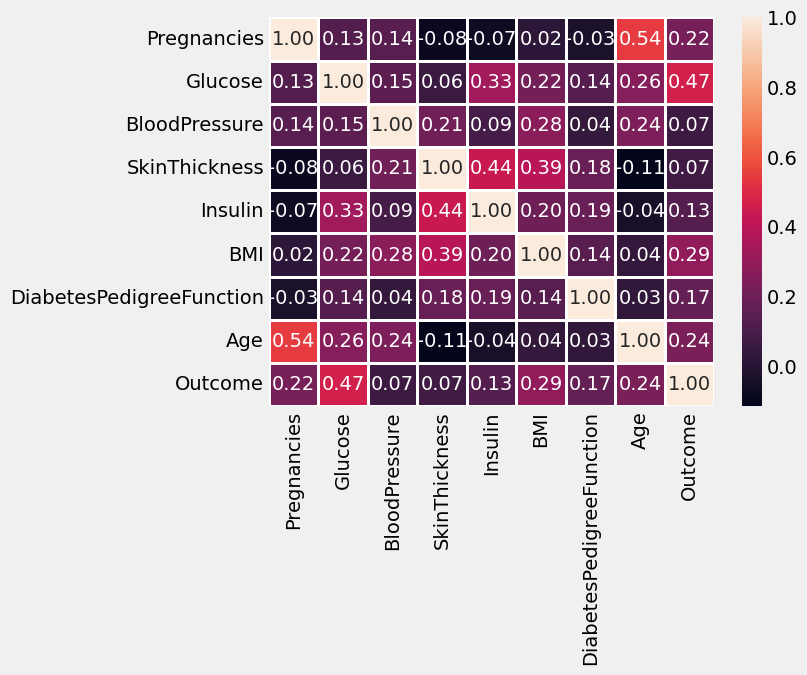

In [9]:
sns.heatmap(df.corr(), annot=True, fmt='0.2f', linewidths=.8)

/tmp/ipykernel_505/1828606462.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette=['#004b45', '#670038'])


<Axes: xlabel='Outcome', ylabel='count'>

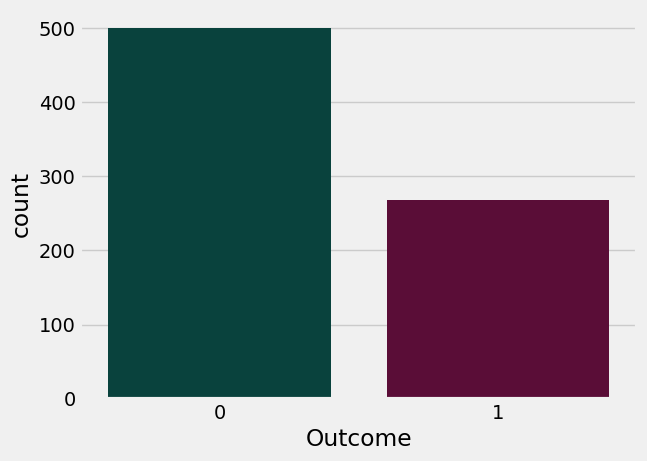

In [10]:
sns.countplot(x='Outcome', data=df, palette=['#004b45', '#670038'])

/tmp/ipykernel_505/152658760.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Pregnancies'])


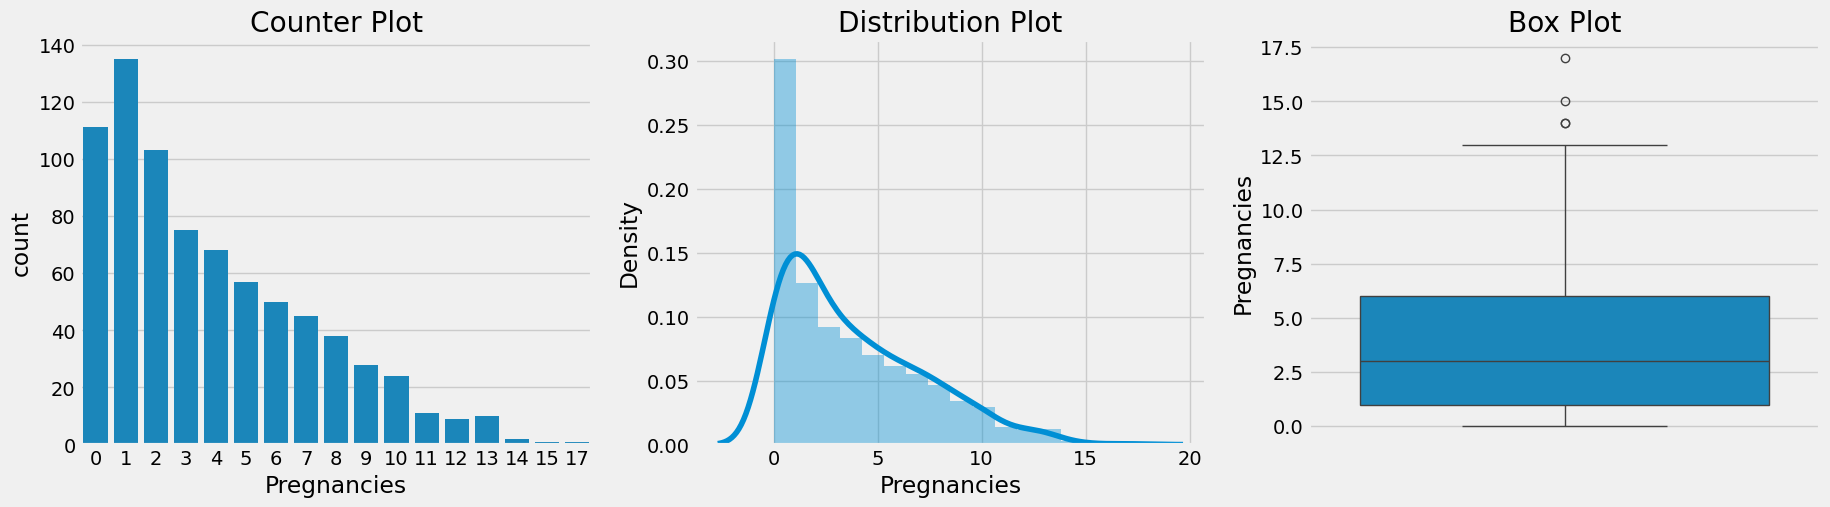

In [11]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 3, 1)
plt.title("Counter Plot")
sns.countplot(x='Pregnancies', data=df)


plt.subplot(1, 3, 2)
plt.title("Distribution Plot")
sns.distplot(df['Pregnancies'])

plt.subplot(1, 3, 3)
plt.title("Box Plot")
sns.boxplot(y=df['Pregnancies'])


plt.show()

<Axes: ylabel='Age'>

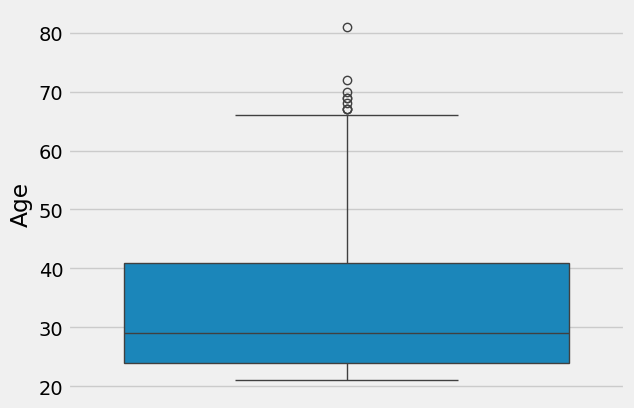

In [14]:
sns.boxplot(df.Age)

# Models

In [18]:
x = df.drop('Outcome', axis=1)

y = df['Outcome']

In [19]:
# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)


In [ ]:
# models = ['LogisticRegression', 'SVC', 'RandomForestClassifier']
models = [LogisticRegression(), SVC(), RandomForestClassifier()]
r1=[]
r2 = []
r3 = []
r4 = []

In [ ]:
def all_metrics(model):
    # Train
    model.fit(x_train, y_train)

    # predect
    pre = model.predict(x_test)

    # calculate the evaluations
    acc = accuracy_score(y_test, pre)
    recall = recall_score(y_test, pre, average='weighted')
    f1 = f1_score(y_test, pre, average='weighted')


    print(f"Model: {type(model).__name__}")
    print("-" * 30)
    print(f"Accuracy Score : {acc:.4f}")
    print(f"Recall Score   : {recall:.4f}")
    print(f"F1 Score       : {f1:.4f}")
    print("-" * 30)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pre))
    print("\nClassification Report:")
    print(classification_report(y_test, pre))

    sns.heatmap(confusion_matrix(y_test, pre), annot=True)

## Model_1: **LogisticRegression**

Model: LogisticRegression
------------------------------
Accuracy Score : 0.7857
Recall Score   : 0.7857
F1 Score       : 0.7797
------------------------------
Confusion Matrix:
[[87 11]
 [22 34]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84        98
           1       0.76      0.61      0.67        56

    accuracy                           0.79       154
   macro avg       0.78      0.75      0.76       154
weighted avg       0.78      0.79      0.78       154



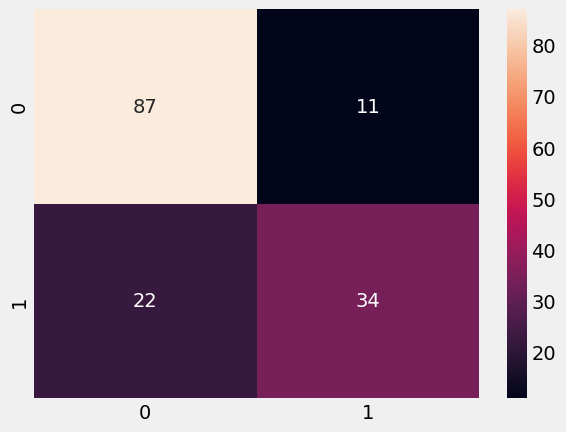

In [35]:
model1= LogisticRegression()
all_metrics(model1)


## Model_2: SVM

Model: SVC
------------------------------
Accuracy Score : 0.7662
Recall Score   : 0.7662
F1 Score       : 0.7573
------------------------------
Confusion Matrix:
[[87 11]
 [25 31]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.89      0.83        98
           1       0.74      0.55      0.63        56

    accuracy                           0.77       154
   macro avg       0.76      0.72      0.73       154
weighted avg       0.76      0.77      0.76       154



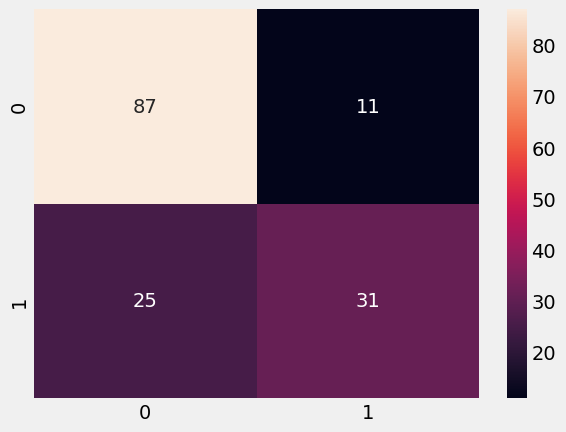

In [30]:
model2 = SVC()
all_metrics(model2)

## Model_3: **RandomForestClassifier**

Model: RandomForestClassifier
------------------------------
Accuracy Score : 0.7792
Recall Score   : 0.7792
F1 Score       : 0.7708
------------------------------
Confusion Matrix:
[[88 10]
 [24 32]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.90      0.84        98
           1       0.76      0.57      0.65        56

    accuracy                           0.78       154
   macro avg       0.77      0.73      0.75       154
weighted avg       0.78      0.78      0.77       154



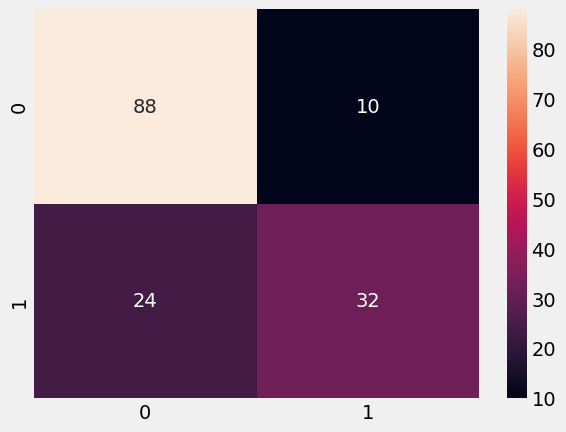

In [31]:
model3 = RandomForestClassifier()
all_metrics(model3)

## Model_4: **GradientBoostingClassifier**

Model: GradientBoostingClassifier
------------------------------
Accuracy Score : 0.7532
Recall Score   : 0.7532
F1 Score       : 0.7456
------------------------------
Confusion Matrix:
[[85 13]
 [25 31]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.87      0.82        98
           1       0.70      0.55      0.62        56

    accuracy                           0.75       154
   macro avg       0.74      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



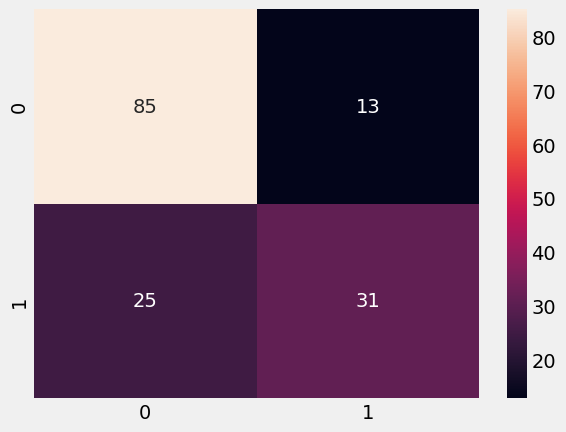

In [33]:
model4 = GradientBoostingClassifier()
all_metrics(model4)